<a href="https://colab.research.google.com/github/HelloShagun/useful_libs/blob/main/examples/GLOF_v2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install earthengine-api geemap geopandas shapely scipy -q

import ee
import geemap
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from shapely.geometry import shape
from pathlib import Path
import json, time, warnings
warnings.filterwarnings('ignore')

ee.Authenticate()
ee.Initialize(project='ee-shagungargc2020')
print('GEE ready ✓')

In [ ]:
# ── Assets ────────────────────────────────────────────────────────────────────
INVENTORY_ASSET = 'projects/ee-shagungargc2020/assets/Saurabh_Vijay_GLOF_2022'
EMBED_COL       = 'GOOGLE/SATELLITE_EMBEDDING/V1/ANNUAL'
YEAR            = 2022

# ── Grid ──────────────────────────────────────────────────────────────────────
PATCH_SIZE      = 0.5     # degrees
PATCH_OVERLAP   = 0.05    # overlap to catch edge lakes — deduplicate later

# ── Detection ─────────────────────────────────────────────────────────────────
MIN_LAKE_AREA_M2  = 400   # 9 pixels @ 10m
#SLOPE_THRESHOLD   = 25    # degrees (skip if DEM unavailable)
BUFFER_INWARD_M   = 20    # inward buffer for reference sampling
MIN_AREA_FOR_BUF  = 3000  # only buffer lakes larger than this
GLACIER_ALPHA     = 0.3   # how hard to push reference away from glaciers
N_SAMPLE_PTS      = 150   # target reference sample points
T_DETECT_FLOOR = 0.90

# ── Confidence anchors (from Cell 2 sanity check — update per patch) ─────────
# These will be computed dynamically per patch
# Hardcoded here as fallback
LAKE_MEAN_FALLBACK  = 0.960
LAKE_P10_FALLBACK   = 0.929
PATCH_MEAN_FALLBACK = 0.802

# ── Output ────────────────────────────────────────────────────────────────────
OUTPUT_DIR    = Path('./glacial_lakes_output')
OUTPUT_DIR.mkdir(exist_ok=True)
DRIVE_FOLDER  = 'GlacialLakes_AlphaEarth'
OUTPUT_NAME   = f'hma_glacial_lakes_alphaearth_{YEAR}'

print('Config ✓')

Config ✓


In [ ]:
inventory = ee.FeatureCollection(INVENTORY_ASSET)
emb_2022  = (ee.ImageCollection(EMBED_COL)
               .filter(ee.Filter.calendarRange(YEAR, YEAR, 'year'))
               .mosaic())
band_names = emb_2022.bandNames().getInfo()
print(f'Inventory: {inventory.size().getInfo():,} lakes')
print(f'Embedding: {len(band_names)} bands')

# ── Test patch (Eastern Himalaya — dense lakes) ───────────────────────────────
PATCH_LON0, PATCH_LAT0 = 88.0, 27.5
PATCH_LON1, PATCH_LAT1 = PATCH_LON0 + PATCH_SIZE, PATCH_LAT0 + PATCH_SIZE

# Detection geometry: with overlap (catches edge lakes)
# Deduplication geometry: exact patch (used for overlap removal later)
patch_detect = ee.Geometry.BBox(
    PATCH_LON0 - PATCH_OVERLAP, PATCH_LAT0 - PATCH_OVERLAP,
    PATCH_LON1 + PATCH_OVERLAP, PATCH_LAT1 + PATCH_OVERLAP)
patch_exact  = ee.Geometry.BBox(
    PATCH_LON0, PATCH_LAT0, PATCH_LON1, PATCH_LAT1)

lakes_in_patch = inventory.filterBounds(patch_exact)
print(f'Lakes in test patch: {lakes_in_patch.size().getInfo()}')

Inventory: 31,698 lakes
Embedding: 64 bands
Lakes in test patch: 150


In [ ]:
def build_similarity(emb_img, lakes_fc, patch_geom, band_names,
                     buffer_m=BUFFER_INWARD_M,
                     min_area_buf=MIN_AREA_FOR_BUF,
                     glacier_alpha=GLACIER_ALPHA,
                     n_pts=N_SAMPLE_PTS,
                     cached_ref_vec=None):
    """
    Build cosine similarity image for one patch.
    Returns: similarity ee.Image, diagnostics dict
    """
    diag = {}

    # ── 1. Sample lake interior pixels ───────────────────────────────────────
    large_lakes    = lakes_fc.filter(ee.Filter.gt('Area', min_area_buf))
    lakes_buffered = (large_lakes
                        .map(lambda f: f.buffer(-buffer_m)
                                        .set('orig_area', f.get('Area')))
                        .map(lambda f: f.set(
                            'buf_area', f.geometry().area(maxError=1)))
                        .filter(ee.Filter.gt('buf_area', 0)))

    n_lakes      = lakes_buffered.size().getInfo()
    pts_per_lake = max(2, min(5, n_pts // max(n_lakes, 1)))

    lake_pts = (lakes_buffered
                  .map(lambda f: ee.FeatureCollection.randomPoints(
                      region=f.geometry(),
                      points=pts_per_lake,
                      seed=42))
                  .flatten())

    samples = emb_img.sampleRegions(
        collection=lake_pts,
        scale=10,
        tileScale=4,
        geometries=False)

    # ── 2. Pull to numpy, find core cluster ───────────────────────────────────
    feats = samples.getInfo()['features']
    X     = np.array([[f['properties'][b] for b in band_names]
                       for f in feats])
    X     = X / (np.linalg.norm(X, axis=1, keepdims=True) + 1e-8)

    sim_mat          = X @ X.T
    mean_sim_others  = sim_mat.mean(axis=1)
    core_mask        = mean_sim_others >= np.percentile(mean_sim_others, 20)
    X_core           = X[core_mask]

    diag['n_samples']      = len(X)
    diag['n_core']         = int(core_mask.sum())
    diag['inter_lake_sim'] = float((X_core @ X_core.T).mean())

    print(f'  Samples: {diag["n_samples"]} → core: {diag["n_core"]}')
    print(f'  Inter-lake sim: {diag["inter_lake_sim"]:.4f}')

    # ── 3. Build reference vector ─────────────────────────────────────────────
    if cached_ref_vec is not None:
        ref_final          = cached_ref_vec
        diag['ref_source'] = 'cached_2022'
        print(f'  Using cached reference vector')
    else:
        ref_vec = X_core.mean(axis=0)
        ref_vec = ref_vec / (np.linalg.norm(ref_vec) + 1e-8)

        # ── 4. Glacier contrast ───────────────────────────────────────────────
        glaciers   = (ee.FeatureCollection('GLIMS/current')
                        .filterBounds(patch_geom))
        n_glaciers = glaciers.size().getInfo()
        diag['n_glacier_polys'] = n_glaciers

        if n_glaciers > 0:
            glaciers_sample = glaciers.limit(20)
            glacier_pts     = glaciers_sample.map(lambda f:
                ee.FeatureCollection.randomPoints(
                    region=f.geometry().simplify(maxError=100),
                    points=5, seed=7)
            ).flatten()

            glacier_samp = emb_img.sampleRegions(
                collection=glacier_pts,
                scale=10,
                tileScale=4,
                geometries=False)

            g_feats   = glacier_samp.getInfo()['features']
            X_g       = np.array([[f['properties'][b] for b in band_names]
                                   for f in g_feats])
            X_g       = X_g / (np.linalg.norm(X_g, axis=1, keepdims=True) + 1e-8)
            g_mean    = X_g.mean(axis=0)
            g_mean    = g_mean / (np.linalg.norm(g_mean) + 1e-8)

            lake_glacier_sim  = float(ref_vec @ g_mean)
            glacier_component = (ref_vec @ g_mean) * g_mean

            # Adaptive alpha — push harder when more confused
            alpha = float(np.clip((lake_glacier_sim - 0.70) / 0.30 * 0.5, 0.05, 0.5))
            ref_contrast = ref_vec - alpha * glacier_component
            ref_contrast = ref_contrast / (np.linalg.norm(ref_contrast) + 1e-8)
            new_lg_sim   = float(ref_contrast @ g_mean)

            diag['lake_glacier_sim_before'] = lake_glacier_sim
            diag['lake_glacier_sim_after']  = new_lg_sim
            diag['glacier_alpha']           = alpha
            ref_final = ref_contrast

            print(f'  Lake-glacier sim: {lake_glacier_sim:.4f} '
                  f'→ {new_lg_sim:.4f}  (α={alpha:.2f})')
        else:
            diag['lake_glacier_sim_before'] = None
            diag['lake_glacier_sim_after']  = None
            diag['glacier_alpha']           = 0.0
            ref_final = ref_vec
            print(f'  No glaciers in patch')

        diag['ref_source'] = 'computed'

    # ── 5. Build GEE similarity image ─────────────────────────────────────────
    ref_img    = ee.Image.constant(ref_final.tolist()).rename(band_names)
    similarity = (emb_img
                    .multiply(ref_img)
                    .reduce(ee.Reducer.sum())
                    .add(1).divide(2)
                    .rename('sim'))

    # ── 6. Patch stats ────────────────────────────────────────────────────────
    patch_stats = similarity.reduceRegion(
        reducer=ee.Reducer.mean()
                  .combine(ee.Reducer.stdDev(), sharedInputs=True),
        geometry=patch_geom,
        scale=20,
        maxPixels=1e7,
        bestEffort=True
    ).getInfo()

    patch_mean = patch_stats.get('sim_mean',   PATCH_MEAN_FALLBACK)
    patch_std  = patch_stats.get('sim_stdDev', 0.04)
    print(f'  Raw patch_stats: {patch_stats}')

    # ── 7. Lake stats ─────────────────────────────────────────────────────────
    lake_stats = similarity.reduceRegion(
        reducer=ee.Reducer.mean()
                  .combine(ee.Reducer.percentile([10]), sharedInputs=True),
        geometry=large_lakes.geometry().simplify(maxError=30),
        scale=10,
        maxPixels=1e6,
        bestEffort=True
    ).getInfo()

    lake_mean = lake_stats.get('sim_mean', LAKE_MEAN_FALLBACK)
    lake_p10  = lake_stats.get('sim_p10',  LAKE_P10_FALLBACK)

    # ── 8. Cluster-based threshold ────────────────────────────────────────────
    sim_to_ref     = X_core @ ref_final
    cluster_mean   = float(np.mean(sim_to_ref))
    cluster_std    = float(np.std(sim_to_ref))
    t_from_cluster = cluster_mean - 1.0 * cluster_std

    # ── 9. Background guard ───────────────────────────────────────────────────
    t_from_patch = patch_mean + 1.5 * patch_std

    # ── 10. Final T_DETECT ────────────────────────────────────────────────────
    t_detect = max(t_from_cluster, t_from_patch, T_DETECT_FLOOR)

    print(f'  cluster_mean={cluster_mean:.4f}  cluster_std={cluster_std:.4f}')
    print(f'  t_from_cluster = {t_from_cluster:.4f}')
    print(f'  t_from_patch   = {t_from_patch:.4f}  '
          f'(mean={patch_mean:.4f} + 1.5σ={patch_std:.4f})')
    print(f'  T_FLOOR        = {T_DETECT_FLOOR}')
    print(f'  T_DETECT       = {t_detect:.4f}')
    print(f'  Separation     : {lake_mean - patch_mean:.4f}')

    # ── 11. Store diagnostics ─────────────────────────────────────────────────
    diag['lake_mean']       = lake_mean
    diag['lake_p10']        = lake_p10
    diag['patch_mean']      = patch_mean
    diag['patch_std']       = patch_std
    diag['cluster_mean']    = cluster_mean
    diag['cluster_std']     = cluster_std
    diag['t_from_cluster']  = t_from_cluster
    diag['t_from_patch']    = t_from_patch
    diag['t_detect']        = t_detect
    diag['separation']      = lake_mean - patch_mean
    diag['weak_patch']      = int(diag['separation'] < 0.05
                                  or t_detect == T_DETECT_FLOOR)
    diag['t_source']        = (
        'cluster' if t_detect == t_from_cluster else
        'patch'   if t_detect == t_from_patch   else
        'floor'
    )

    return similarity, diag

  Samples: 298 → core: 238
  Inter-lake sim: 0.9355
  Lake-glacier sim: 0.8264 → 0.7570  (α=0.21)
  Raw patch_stats: {'sim_mean': 0.8049706329698282, 'sim_stdDev': 0.06688888671565639}
  cluster_mean=0.9609  cluster_std=0.0176
  t_from_cluster = 0.9434
  t_from_patch   = 0.9053  (mean=0.8050 + 1.5σ=0.0669)
  T_FLOOR        = 0.9
  T_DETECT       = 0.9434
  Separation     : 0.1613
dict_keys(['n_samples', 'n_core', 'inter_lake_sim', 'n_glacier_polys', 'lake_glacier_sim_before', 'lake_glacier_sim_after', 'glacier_alpha', 'ref_source', 'lake_mean', 'lake_p10', 'patch_mean', 'patch_std', 'cluster_mean', 'cluster_std', 't_from_cluster', 't_from_patch', 't_detect', 'separation', 'weak_patch', 't_source'])
cluster_mean = 0.9609
T_DETECT = 0.9434


In [ ]:
def detect_and_score(similarity, patch_geom, lakes_fc,
                     t_detect, diag,
                     min_area=MIN_LAKE_AREA_M2):
    """
    Detect lake polygons and compute all attributes.
    Returns GeoDataFrame with full attribute set.
    """

    # ── Binarise ──────────────────────────────────────────────────────────────
    binary = similarity.gt(t_detect).selfMask()

    # ── Slope mask (only if DEM available) ───────────────────────────────────
    has_dem = False

    # ── Vectorise ─────────────────────────────────────────────────────────────
    vectors = binary.reduceToVectors(
        geometry=patch_geom,
        scale=10,
        geometryType='polygon',
        eightConnected=True,
        maxPixels=1e8,
        bestEffort=True
    )
    vectors = (vectors
        .map(lambda f: f.set('area_m2', f.geometry().area(maxError=1)))
        .filter(ee.Filter.gte('area_m2', min_area)))

    n_cand = vectors.size().getInfo()
    print(f'  Candidates: {n_cand}')
    if n_cand == 0:
        return None

    # ── Batch similarity stats ────────────────────────────────────────────────
    vectors_stats = similarity.reduceRegions(
        collection=vectors,
        reducer=(ee.Reducer.mean()
                   .combine(ee.Reducer.stdDev(),              sharedInputs=True)
                   .combine(ee.Reducer.percentile([10, 90]),  sharedInputs=True)
                   .combine(ee.Reducer.count(),               sharedInputs=True)),
        scale=10, tileScale=4)

    # ── Elevation at centroid (if DEM available) ──────────────────────────────
    if has_dem:
        vectors_stats = dem.reduceRegions(
            collection=vectors_stats,
            reducer=ee.Reducer.mean().setOutputs(['elevation_m']),
            scale=30, tileScale=4)
        vectors_stats = slope.reduceRegions(
            collection=vectors_stats,
            reducer=ee.Reducer.mean().setOutputs(['slope_mean']),
            scale=30, tileScale=4)

    # ── Inventory flag ────────────────────────────────────────────────────────
    inv_image     = ee.Image(0).paint(lakes_fc, 1).rename('in_inventory')
    vectors_stats = inv_image.reduceRegions(
        collection=vectors_stats,
        reducer=ee.Reducer.max().setOutputs(['in_inventory']),
        scale=10, tileScale=4)

    # ── Inventory matched area ────────────────────────────────────────────────
    # Paint inventory area values so we can retrieve matched lake's area
    inv_area_img  = ee.Image(0).paint(lakes_fc,
        ee.Number(lakes_fc.first().get('Area')))
    vectors_stats = inv_area_img.rename('inv_area').reduceRegions(
        collection=vectors_stats,
        reducer=ee.Reducer.max().setOutputs(['inv_matched_area_m2']),
        scale=10, tileScale=4)

    # ── Perimeter (for shape index) ───────────────────────────────────────────
    vectors_stats = vectors_stats.map(
        lambda f: f.set('perimeter_m', f.geometry().perimeter(maxError=1)))

    # ── Pull to Colab ─────────────────────────────────────────────────────────
    features = vectors_stats.getInfo()['features']
    print(f'  Retrieved {len(features)} features')

    # ── Build GeoDataFrame ────────────────────────────────────────────────────
    rows, geoms = [], []
    for f in features:
        p = f['properties']
        rows.append(p)
        geoms.append(shape(f['geometry']))

    gdf = gpd.GeoDataFrame(rows, geometry=geoms, crs='EPSG:4326')

    # Rename reduceRegions output columns
    gdf = gdf.rename(columns={
        'mean'   : 'sim_mean',
        'stdDev' : 'sim_std',
        'p10'    : 'sim_p10',
        'p90'    : 'sim_p90',
        'count'  : 'n_pixels',
        'max'    : 'in_inventory',
    })

    # ── Confidence components (pandas — instant) ──────────────────────────────
    lake_mean  = diag['lake_mean']
    lake_p10   = diag['lake_p10']
    patch_mean = diag['patch_mean']

    # sim_score dropped — T_DETECT already gates on similarity
    # confidence = quality within the detected set only
    gdf['compactness']  = (1 - (gdf['sim_std']
                          / (gdf['sim_mean'] + 1e-8)).clip(0, 1))
    gdf['floor_margin'] = ((gdf['sim_p10'] - t_detect)
                          / (diag['cluster_mean'] - t_detect + 1e-8)).clip(0, 1)
    gdf['size_score']   = 1 / (1 + np.exp(-0.003 * (gdf['area_m2'] - 900)))
    gdf['confidence']   = (gdf['size_score']   ** 0.50
                        * gdf['compactness']  ** 0.30
                        * gdf['floor_margin'] ** 0.20)

    # ── Geometric attributes ──────────────────────────────────────────────────
    gdf['area_km2']    = gdf['area_m2'] / 1e6
    gdf_proj           = gdf.to_crs('EPSG:6933')  # equal area
    gdf['area_m2']     = gdf_proj.geometry.area   # recompute accurately
    gdf['perimeter_m'] = gdf_proj.geometry.length
    gdf['shape_index'] = (4 * np.pi * gdf['area_m2']
                          / (gdf['perimeter_m'] ** 2 + 1e-8)).clip(0, 1)
    gdf               = gdf.to_crs('EPSG:4326')

    cen = gdf.geometry.centroid
    gdf['centroid_lon'] = cen.x
    gdf['centroid_lat'] = cen.y

    # ── Patch metadata (reproducibility) ─────────────────────────────────────
    gdf['patch_id']              = f'{PATCH_LON0:.2f}_{PATCH_LAT0:.2f}'
    gdf['t_detect']              = t_detect
    gdf['lake_mean_ref']         = lake_mean
    gdf['lake_p10_ref']          = lake_p10
    gdf['patch_mean_ref']        = patch_mean
    gdf['glacier_alpha']         = diag.get('glacier_alpha', 0)
    gdf['lake_glacier_sim']      = diag.get('lake_glacier_sim_before', np.nan)
    gdf['inter_lake_sim']        = diag.get('inter_lake_sim', np.nan)
    gdf['has_dem']               = has_dem
    gdf['year']                  = YEAR
    gdf['lake_id']               = [f'GL_{PATCH_LON0:.2f}_{PATCH_LAT0:.2f}_{i:04d}'
                                    for i in range(len(gdf))]

    # ── Edge flag: centroid within 0.05° of patch boundary ───────────────────
    gdf['is_edge'] = (
        (gdf['centroid_lon'] < PATCH_LON0 + PATCH_OVERLAP) |
        (gdf['centroid_lon'] > PATCH_LON1 - PATCH_OVERLAP) |
        (gdf['centroid_lat'] < PATCH_LAT0 + PATCH_OVERLAP) |
        (gdf['centroid_lat'] > PATCH_LAT1 - PATCH_OVERLAP)
    ).astype(int)

    gdf = gdf.sort_values('confidence', ascending=False).reset_index(drop=True)
    return gdf


print('Detecting and scoring...')
gdf = detect_and_score(similarity, patch_detect, lakes_in_patch,
                        T_DETECT, diag)

Detecting and scoring...
  Candidates: 487
  Retrieved 487 features


  Total detections   : 487
  In inventory       : 148  (30.4%)
  Novel lakes        : 339
  Edge lakes         : 264

  Confidence tiers:
    High   (>0.7)    :  213
    Medium (0.4–0.7) :  167
    Low    (<0.4)    :  107

  Size breakdown:
    < 1000 m²        :   92
    1000–3600 m²     :  127
    > 3600 m²        :  268

  Area stats:
    Total area       : 20.328 km²
    Median lake      : 4402 m²
    Largest lake     : 1562653 m²

  Top 10 by confidence:
            lake_id     area_m2  sim_mean  confidence  shape_index  in_inventory  is_edge
GL_88.00_27.50_0393  252872.065     0.965       0.998        0.435             0        1
GL_88.00_27.50_0328  607326.675     0.968       0.998        0.320             1        0
GL_88.00_27.50_0203 1463723.955     0.973       0.998        0.304             1        0
GL_88.00_27.50_0272  113131.597     0.972       0.998        0.517             1        0
GL_88.00_27.50_0345  550272.709     0.975       0.998        0.262             0      

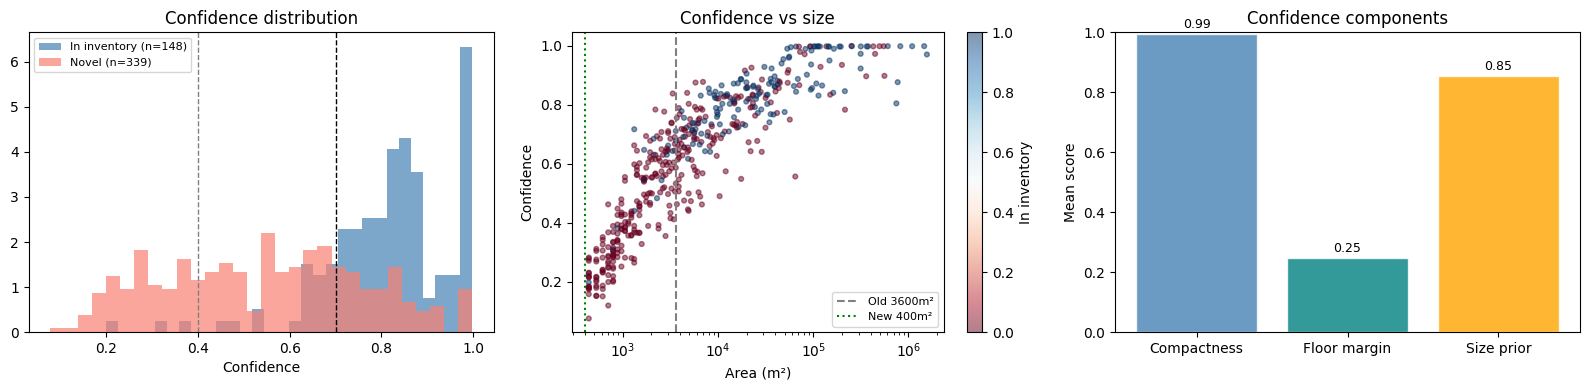

In [ ]:
inv = gdf.in_inventory == 1
nov = gdf.in_inventory == 0

print(f'{"="*55}')
print(f'  Total detections   : {len(gdf)}')
print(f'  In inventory       : {inv.sum()}  ({100*inv.mean():.1f}%)')
print(f'  Novel lakes        : {nov.sum()}')
print(f'  Edge lakes         : {gdf.is_edge.sum()}')
print(f'{"="*55}')
print(f'\n  Confidence tiers:')
print(f'    High   (>0.7)    : {(gdf.confidence>0.7).sum():4d}')
print(f'    Medium (0.4–0.7) : {((gdf.confidence>=0.4)&(gdf.confidence<=0.7)).sum():4d}')
print(f'    Low    (<0.4)    : {(gdf.confidence<0.4).sum():4d}')
print(f'\n  Size breakdown:')
print(f'    < 1000 m²        : {(gdf.area_m2<1000).sum():4d}')
print(f'    1000–3600 m²     : {((gdf.area_m2>=1000)&(gdf.area_m2<3600)).sum():4d}')
print(f'    > 3600 m²        : {(gdf.area_m2>=3600).sum():4d}')
print(f'\n  Area stats:')
print(f'    Total area       : {gdf.area_km2.sum():.3f} km²')
print(f'    Median lake      : {gdf.area_m2.median():.0f} m²')
print(f'    Largest lake     : {gdf.area_m2.max():.0f} m²')
print(f'\n  Top 10 by confidence:')
print(gdf[['lake_id','area_m2','sim_mean','confidence',
           'shape_index','in_inventory','is_edge']]
      .head(10).to_string(index=False, float_format='%.3f'))

# ── Plots ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for label, mask, color in [
    ('In inventory', inv, 'steelblue'),
    ('Novel',        nov, 'salmon')]:
    if mask.sum() > 0:
        axes[0].hist(gdf[mask].confidence, bins=30, alpha=0.7,
                     color=color, density=True,
                     label=f'{label} (n={mask.sum()})')
axes[0].axvline(0.4, color='gray',  ls='--', lw=1)
axes[0].axvline(0.7, color='black', ls='--', lw=1)
axes[0].set_xlabel('Confidence')
axes[0].set_title('Confidence distribution')
axes[0].legend(fontsize=8)

sc = axes[1].scatter(gdf.area_m2, gdf.confidence,
                     c=gdf.in_inventory, cmap='RdBu',
                     alpha=0.5, s=12, vmin=0, vmax=1)
axes[1].set_xscale('log')
axes[1].axvline(3600,        color='gray',  ls='--', lw=1.5, label='Old 3600m²')
axes[1].axvline(MIN_LAKE_AREA_M2, color='green', ls=':', lw=1.5,
                label=f'New {MIN_LAKE_AREA_M2}m²')
axes[1].set_xlabel('Area (m²)')
axes[1].set_ylabel('Confidence')
axes[1].set_title('Confidence vs size')
axes[1].legend(fontsize=8)
plt.colorbar(sc, ax=axes[1], label='In inventory')

comp_cols   = ['compactness','floor_margin','size_score']
comp_labels = ['Compactness','Floor margin','Size prior']
colors      = ['steelblue','teal','orange','green']
means       = gdf[comp_cols].mean()
bars        = axes[2].bar(comp_labels, means, color=colors,
                          alpha=0.8, edgecolor='white')
axes[2].set_ylim(0, 1)
axes[2].set_ylabel('Mean score')
axes[2].set_title('Confidence components')
for bar, v in zip(bars, means):
    axes[2].text(bar.get_x() + bar.get_width()/2,
                 v + 0.02, f'{v:.2f}', ha='center', fontsize=9)
plt.tight_layout()
plt.show()

In [ ]:
Map = geemap.Map(center=[(PATCH_LAT0+PATCH_LAT1)/2,
                          (PATCH_LON0+PATCH_LON1)/2], zoom=11)

Map.addLayer(
    similarity.clip(patch_detect),
    {'min': 0.80, 'max': 1.0,
     'palette': ['white','#ffffb2','#fecc5c','#fd8d3c','#e31a1c','#800026']},
    'Similarity')

# Rebuild vectors_final from gdf for GEE display
vectors_ee = geemap.geopandas_to_ee(
    gdf[['confidence','in_inventory','is_edge','geometry']])

high = vectors_ee.filter(ee.Filter.gte('confidence', 0.7))
med  = vectors_ee.filter(
    ee.Filter.And(ee.Filter.gte('confidence', 0.4),
                  ee.Filter.lt( 'confidence', 0.7)))
low  = vectors_ee.filter(ee.Filter.lt('confidence', 0.4))

Map.addLayer(low,  {'color': 'ADD8E6', 'fillColor': 'ADD8E640'}, 'Low conf')
Map.addLayer(med,  {'color': '0080FF', 'fillColor': '0080FF60'}, 'Med conf')
Map.addLayer(high, {'color': '00008B', 'fillColor': '00008B80'}, 'High conf')
Map.addLayer(lakes_in_patch,
             {'color': 'FF0000', 'fillColor': '00000000', 'width': 2},
             'Inventory 2022')
Map.addLayerControl()
display(Map)

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
#  CELL 7 — Save GeoPackage + similarity image to Google Drive
# ═══════════════════════════════════════════════════════════════════════════════

def save_patch_to_drive(gdf, similarity_img, patch_geom,
                        patch_id, drive_folder=DRIVE_FOLDER):
    """
    Save:
      1. GeoPackage (lake polygons + all attributes) → local + Drive
      2. Similarity GeoTIFF → Drive via GEE Export
    """
    results = {}

    # ── 1. Save GeoPackage locally first ─────────────────────────────────────
    if gdf is not None and len(gdf) > 0:
        local_path = OUTPUT_DIR / f'patch_{patch_id}.gpkg'
        gdf.to_file(local_path, driver='GPKG')
        size_mb = local_path.stat().st_size / 1e6
        print(f'✓ GeoPackage saved locally: {local_path}  ({size_mb:.2f} MB)')
        results['local_gpkg'] = str(local_path)
    else:
        print('No lakes to save')
        return results

    # ── 2. Save GeoPackage to Google Drive via Colab ──────────────────────────
    # Mount drive if not already mounted
    try:
        from google.colab import drive
        import shutil, os
        drive.mount('/content/drive', force_remount=False)

        drive_dir = Path(f'/content/drive/MyDrive/{drive_folder}')
        drive_dir.mkdir(parents=True, exist_ok=True)

        drive_gpkg = drive_dir / f'patch_{patch_id}.gpkg'
        shutil.copy(local_path, drive_gpkg)
        print(f'✓ GeoPackage saved to Drive: {drive_gpkg}')
        results['drive_gpkg'] = str(drive_gpkg)

        # Also save patch diagnostics as JSON
        diag_path = drive_dir / f'patch_{patch_id}_diag.json'
        diag_out  = {
            'patch_id'              : patch_id,
            'n_lakes'               : len(gdf),
            'n_inventory_match'     : int(gdf.in_inventory.sum()),
            'n_novel'               : int((gdf.in_inventory == 0).sum()),
            'n_edge'                : int(gdf.is_edge.sum()),
            'confidence_mean'       : float(gdf.confidence.mean()),
            'confidence_high_n'     : int((gdf.confidence > 0.7).sum()),
            't_detect'              : float(gdf.t_detect.iloc[0]),
            'lake_mean_ref'         : float(gdf.lake_mean_ref.iloc[0]),
            'lake_p10_ref'          : float(gdf.lake_p10_ref.iloc[0]),
            'patch_mean_ref'        : float(gdf.patch_mean_ref.iloc[0]),
            'lake_glacier_sim'      : float(gdf.lake_glacier_sim.iloc[0])
                                      if gdf.lake_glacier_sim.iloc[0] else None,
            'inter_lake_sim'        : float(gdf.inter_lake_sim.iloc[0]),
            'total_area_km2'        : float(gdf.area_km2.sum()),
            'median_area_m2'        : float(gdf.area_m2.median()),
        }
        with open(diag_path, 'w') as f:
            json.dump(diag_out, f, indent=2)
        print(f'✓ Diagnostics saved: {diag_path}')
        results['diag'] = diag_out

    except Exception as e:
        print(f'Drive copy failed: {e}')
        print('  (Run in Colab with Drive mounted)')

    # ── 3. Export similarity GeoTIFF to Drive via GEE ─────────────────────────
    # This runs asynchronously — check status with task.status()
    lon0 = float(patch_id.split('_')[0])
    lat0 = float(patch_id.split('_')[1])

    export_task = ee.batch.Export.image.toDrive(
        image=similarity_img.clip(patch_geom).toFloat(),
        description=f'similarity_{patch_id}',
        folder=drive_folder,
        fileNamePrefix=f'similarity_{patch_id}',
        region=patch_geom,
        scale=10,
        crs='EPSG:4326',
        maxPixels=1e9,
        fileFormat='GeoTIFF'
    )
    export_task.start()
    print(f'✓ Similarity GeoTIFF export started (async)')
    print(f'  Task ID: {export_task.id}')
    print(f'  Monitor: https://code.earthengine.google.com/tasks')
    results['similarity_task_id'] = export_task.id
    results['similarity_task']    = export_task

    return results


# ── Run ───────────────────────────────────────────────────────────────────────
patch_id = f'{PATCH_LON0:.2f}_{PATCH_LAT0:.2f}'
results  = save_patch_to_drive(gdf, similarity, patch_detect, patch_id)

# ── Monitor export task ───────────────────────────────────────────────────────
if 'similarity_task' in results:
    import time
    task = results['similarity_task']
    print(f'\nMonitoring similarity export...')
    for _ in range(12):   # check for up to 2 minutes
        status = task.status()
        state  = status['state']
        print(f'  {state}')
        if state in ('COMPLETED', 'FAILED', 'CANCELLED'):
            break
        time.sleep(10)
    if state == 'COMPLETED':
        print(f'✓ Similarity GeoTIFF exported to Drive/{DRIVE_FOLDER}/')
    elif state == 'FAILED':
        print(f'✗ Export failed: {status.get("error_message")}')
    else:
        print(f'Still running — check https://code.earthengine.google.com/tasks')

✓ GeoPackage saved locally: glacial_lakes_output/patch_88.00_27.50.gpkg  (0.76 MB)
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✓ GeoPackage saved to Drive: /content/drive/MyDrive/GlacialLakes_AlphaEarth/patch_88.00_27.50.gpkg
✓ Diagnostics saved: /content/drive/MyDrive/GlacialLakes_AlphaEarth/patch_88.00_27.50_diag.json
✓ Similarity GeoTIFF export started (async)
  Task ID: 7XNFCFQYGZ5O4HQM242LQCJV
  Monitor: https://code.earthengine.google.com/tasks

Monitoring similarity export...
  READY
  RUNNING
  RUNNING
  RUNNING
  RUNNING
  RUNNING
  RUNNING
  RUNNING
  RUNNING
  RUNNING
  RUNNING
  RUNNING
Still running — check https://code.earthengine.google.com/tasks


## Batch Processing

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
#  CELL 8 — Build patch grid covering all inventory lakes
# ═══════════════════════════════════════════════════════════════════════════════

def build_patch_grid(inventory, patch_size=PATCH_SIZE):

    # Use centroid coordinates — avoids dissolving all polygons
    lon_min = np.floor(inventory.aggregate_min('Longitude').getInfo() / patch_size) * patch_size
    lon_max = np.ceil( inventory.aggregate_max('Longitude').getInfo() / patch_size) * patch_size
    lat_min = np.floor(inventory.aggregate_min('Latitude').getInfo()  / patch_size) * patch_size
    lat_max = np.ceil( inventory.aggregate_max('Latitude').getInfo()  / patch_size) * patch_size

    lon_steps = np.arange(lon_min, lon_max, patch_size)
    lat_steps = np.arange(lat_min, lat_max, patch_size)

    print(f'HMA extent: lon [{lon_min}→{lon_max}]  lat [{lat_min}→{lat_max}]')
    print(f'Grid: {len(lon_steps)} × {len(lat_steps)} = '
          f'{len(lon_steps)*len(lat_steps)} total cells')

    # Check which cells contain lakes
    # Do this in one GEE call using a spatial join approach — much faster
    # than looping filterBounds per cell
    patches = []
    for lon0 in lon_steps:
        for lat0 in lat_steps:
            lon1 = round(lon0 + patch_size, 4)
            lat1 = round(lat0 + patch_size, 4)
            patches.append({
                'lon0': round(float(lon0), 4),
                'lat0': round(float(lat0), 4),
                'lon1': lon1,
                'lat1': lat1,
                'patch_id': f'{lon0:.2f}_{lat0:.2f}'
            })

    # Filter in batches of 50 to avoid GEE timeout
    valid_patches = []
    batch_size    = 50
    for i in range(0, len(patches), batch_size):
        batch = patches[i:i+batch_size]
        for p in batch:
            cell = ee.Geometry.BBox(p['lon0'], p['lat0'],
                                    p['lon1'], p['lat1'])
            n    = inventory.filterBounds(cell).size().getInfo()
            if n > 0:
                p['n_inventory_lakes'] = n
                valid_patches.append(p)
        print(f'  Checked {min(i+batch_size, len(patches))}'
              f'/{len(patches)} cells — '
              f'{len(valid_patches)} valid so far')

    print(f'\nFinal grid: {len(valid_patches)} patches with lakes')
    return valid_patches


# Build and save grid
patch_grid = build_patch_grid(inventory)

# Save grid for reference
grid_df   = pd.DataFrame(patch_grid)
grid_path = OUTPUT_DIR / 'patch_grid.csv'
grid_df.to_csv(grid_path, index=False)
print(f'Grid saved: {grid_path}')
print(grid_df.head(10).to_string())

HMA extent: lon [67.0→104.0]  lat [26.5→45.5]
Grid: 74 × 38 = 2812 total cells
  Checked 50/2812 cells — 1 valid so far
  Checked 100/2812 cells — 5 valid so far
  Checked 150/2812 cells — 11 valid so far
  Checked 200/2812 cells — 15 valid so far
  Checked 250/2812 cells — 23 valid so far
  Checked 300/2812 cells — 39 valid so far
  Checked 350/2812 cells — 51 valid so far
  Checked 400/2812 cells — 65 valid so far
  Checked 450/2812 cells — 88 valid so far
  Checked 500/2812 cells — 101 valid so far
  Checked 550/2812 cells — 120 valid so far
  Checked 600/2812 cells — 149 valid so far
  Checked 650/2812 cells — 168 valid so far
  Checked 700/2812 cells — 186 valid so far
  Checked 750/2812 cells — 208 valid so far
  Checked 800/2812 cells — 229 valid so far
  Checked 850/2812 cells — 251 valid so far
  Checked 900/2812 cells — 274 valid so far
  Checked 950/2812 cells — 294 valid so far
  Checked 1000/2812 cells — 317 valid so far
  Checked 1050/2812 cells — 339 valid so far
  Check

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
#  CELL 9 — Process all patches with checkpointing
# ═══════════════════════════════════════════════════════════════════════════════
import traceback

CHECKPOINT_DIR  = OUTPUT_DIR / 'checkpoints'
CHECKPOINT_DIR.mkdir(exist_ok=True)
EXPORT_SIM_TIFS = False   # set True to also export similarity GeoTIFFs
                           # warning: slow, uses GEE quota fast


def patch_is_done(patch_id):
    """Check if patch already processed (checkpoint exists)."""
    return (CHECKPOINT_DIR / f'{patch_id}.done').exists()


def mark_patch_done(patch_id):
    (CHECKPOINT_DIR / f'{patch_id}.done').touch()


def mark_patch_failed(patch_id, error):
    with open(CHECKPOINT_DIR / f'{patch_id}.failed', 'w') as f:
        f.write(str(error))


def process_patch(patch_info, inventory, emb_2022, band_names,
                  drive_folder=DRIVE_FOLDER):
    """
    Full pipeline for one patch.
    Returns gdf or None if failed.
    """
    patch_id = patch_info['patch_id']
    lon0     = patch_info['lon0']
    lat0     = patch_info['lat0']
    lon1     = patch_info['lon1']
    lat1     = patch_info['lat1']

    # Detection geometry (with overlap)
    patch_detect = ee.Geometry.BBox(
        lon0 - PATCH_OVERLAP, lat0 - PATCH_OVERLAP,
        lon1 + PATCH_OVERLAP, lat1 + PATCH_OVERLAP)

    # Exact geometry (for inventory lookup and edge flagging)
    patch_exact = ee.Geometry.BBox(lon0, lat0, lon1, lat1)

    lakes_in_patch = inventory.filterBounds(patch_exact)
    n_lakes        = patch_info['n_inventory_lakes']

    print(f'\n{"─"*60}')
    print(f'Patch {patch_id}  ({n_lakes} inventory lakes)')

    # ── Build similarity ──────────────────────────────────────────────────────
    emb_patch  = emb_2022.clip(patch_detect)
    similarity, diag = build_similarity(
        emb_patch, lakes_in_patch, patch_detect, band_names)

    # Check separation is reasonable
    if diag['separation'] < 0.03:
        print(f'  WARNING: low separation ({diag["separation"]:.4f}) '
              f'— results may be unreliable')

    T_DETECT = diag['t_detect']

    # ── Skip patch if separation too low ──────────────────────────────────────
    if diag['separation'] < 0.03:
        print(f'  Skipping — separation too low ({diag["separation"]:.4f})')
        mark_patch_failed(patch_id, 'low_separation')
        return None

    # ── Detect and score ──────────────────────────────────────────────────────
    gdf = detect_and_score(
        similarity, patch_detect, lakes_in_patch, T_DETECT, diag)

    if gdf is None or len(gdf) == 0:
        print(f'  No lakes detected — skipping save')
        return None

    # Update edge flag using this patch's actual bounds
    gdf['is_edge'] = (
        (gdf['centroid_lon'] < lon0 + PATCH_OVERLAP) |
        (gdf['centroid_lon'] > lon1 - PATCH_OVERLAP) |
        (gdf['centroid_lat'] < lat0 + PATCH_OVERLAP) |
        (gdf['centroid_lat'] > lat1 - PATCH_OVERLAP)
    ).astype(int)

    # ── Save locally ──────────────────────────────────────────────────────────
    local_path = OUTPUT_DIR / f'patch_{patch_id}.gpkg'
    gdf.to_file(local_path, driver='GPKG')

    # ── Save to Drive ─────────────────────────────────────────────────────────
    try:
        from google.colab import drive
        import shutil
        drive_dir = Path(f'/content/drive/MyDrive/{drive_folder}/patches')
        drive_dir.mkdir(parents=True, exist_ok=True)

        shutil.copy(local_path, drive_dir / f'patch_{patch_id}.gpkg')

        # Save diagnostics JSON
        diag_out = {
                    'patch_id'          : patch_id,
                    'lon0': lon0, 'lat0': lat0, 'lon1': lon1, 'lat1': lat1,
                    'n_inventory_lakes' : n_lakes,
                    'n_detected'        : len(gdf),
                    'n_inventory_match' : int(gdf.in_inventory.sum()),
                    'n_novel'           : int((gdf.in_inventory==0).sum()),
                    'n_edge'            : int(gdf.is_edge.sum()),
                    'n_high_conf'       : int((gdf.confidence>0.7).sum()),
                    'confidence_mean'   : float(gdf.confidence.mean()),
                    'total_area_km2'    : float(gdf.area_km2.sum()),
                    'separation'        : diag['separation'],
                    't_detect'          : diag['t_detect'],
                    't_source'          : diag.get('t_source', 'unknown'),
                    'weak_patch'        : diag.get('weak_patch', 0),
                    'lake_mean'         : diag['lake_mean'],
                    'lake_p10'          : diag['lake_p10'],
                    'patch_mean'        : diag['patch_mean'],
                    'patch_std'         : diag.get('patch_std', 0),
                    'cluster_mean'      : diag.get('cluster_mean', 0),
                    'cluster_std'       : diag.get('cluster_std', 0),
                    'inter_lake_sim'    : diag['inter_lake_sim'],
                    'lake_glacier_sim'  : diag.get('lake_glacier_sim_before'),
                    'glacier_alpha'     : diag.get('glacier_alpha', 0),
                    'n_samples'         : diag.get('n_samples', 0),
                    'n_core'            : diag.get('n_core', 0),
                    'status'            : 'ok'
                }
        with open(drive_dir / f'patch_{patch_id}_diag.json', 'w') as f:
            json.dump(diag_out, f, indent=2)

        print(f'  ✓ Saved to Drive  ({len(gdf)} lakes, '
              f'conf_mean={gdf.confidence.mean():.3f})')

    except Exception as e:
        print(f'  Drive save failed: {e}')

    # ── Optional: export similarity GeoTIFF ───────────────────────────────────
    if EXPORT_SIM_TIFS:
        ee.batch.Export.image.toDrive(
            image=similarity.clip(patch_detect).toFloat(),
            description=f'sim_{patch_id}',
            folder=f'{drive_folder}/similarity',
            fileNamePrefix=f'similarity_{patch_id}',
            region=patch_detect,
            scale=10, crs='EPSG:4326',
            maxPixels=1e9
        ).start()
        print(f'  ✓ Similarity export queued')

    return gdf


# ── Main loop ─────────────────────────────────────────────────────────────────
print(f'Processing {len(patch_grid)} patches...')
print(f'Checkpoints: {CHECKPOINT_DIR}')
print(f'Output:      {OUTPUT_DIR}')
print(f'Drive:       MyDrive/{DRIVE_FOLDER}/patches/')

# Mount Drive once before loop
from google.colab import drive
drive.mount('/content/drive', force_remount=False)

all_results = []
n_done      = sum(patch_is_done(p['patch_id']) for p in patch_grid)
print(f'Already done: {n_done}/{len(patch_grid)} patches\n')

for i, patch_info in enumerate(patch_grid):
    patch_id = patch_info['patch_id']

    # Skip if already processed
    if patch_is_done(patch_id):
        print(f'[{i+1}/{len(patch_grid)}] {patch_id} — already done, skipping')
        continue

    print(f'[{i+1}/{len(patch_grid)}] {patch_id}', end='')

    try:
        gdf = process_patch(
            patch_info, inventory, emb_2022, band_names)

        if gdf is not None:
            all_results.append(gdf)

        mark_patch_done(patch_id)

        # Brief pause to avoid GEE rate limiting
        time.sleep(3)

    except KeyboardInterrupt:
        print('\nInterrupted — progress saved, rerun to continue')
        break

    except Exception as e:
        print(f'\n  ✗ FAILED: {e}')
        traceback.print_exc()
        mark_patch_failed(patch_id, e)
        # Don't stop — continue to next patch
        time.sleep(5)
        continue

print(f'\nLoop complete: {len(all_results)} patches processed this session')

Processing 886 patches...
Checkpoints: glacial_lakes_output/checkpoints
Output:      glacial_lakes_output
Drive:       MyDrive/GlacialLakes_AlphaEarth/patches/
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Already done: 6/886 patches

[1/886] 67.00_38.50 — already done, skipping
[2/886] 67.50_34.50 — already done, skipping
[3/886] 67.50_38.50 — already done, skipping
[4/886] 67.50_39.00
────────────────────────────────────────────────────────────
Patch 67.50_39.00  (25 inventory lakes)
  Samples: 120 → core: 96
  Inter-lake sim: 0.9365
  Lake-glacier sim: 0.7434 → 0.7178  (α=0.07)
  Raw patch_stats: {'sim_mean': 0.6789645280802085, 'sim_stdDev': 0.10586121351166193}
  cluster_mean=0.9671  cluster_std=0.0244
  t_from_cluster = 0.9427
  t_from_patch   = 0.8378  (mean=0.6790 + 1.5σ=0.1059)
  T_FLOOR        = 0.9
  T_DETECT       = 0.9427
  Separation     : 0.1906
  Candidates: 219
  Retrieved 219 features
 

  Samples: 402 → core: 321
  Inter-lake sim: 0.9679


  Lake-glacier sim: 0.6747 → 0.6557  (α=0.05)
  Raw patch_stats: {'sim_mean': 0.8164209669327879, 'sim_stdDev': 0.06737394057758056}
  cluster_mean=0.9835  cluster_std=0.0091
  t_from_cluster = 0.9744
  t_from_patch   = 0.9175  (mean=0.8164 + 1.5σ=0.0674)
  T_FLOOR        = 0.9
  T_DETECT       = 0.9744
  Separation     : 0.1620
  Candidates: 396
  Retrieved 396 features
  ✓ Saved to Drive  (396 lakes, conf_mean=0.749)
[23/886] 70.00_36.00
────────────────────────────────────────────────────────────
Patch 70.00_36.00  (52 inventory lakes)
  Samples: 102 → core: 81
  Inter-lake sim: 0.9679
  Lake-glacier sim: 0.7615 → 0.7256  (α=0.10)
  Raw patch_stats: {'sim_mean': 0.7713545170519037, 'sim_stdDev': 0.0918410539949315}
  cluster_mean=0.9824  cluster_std=0.0067
  t_from_cluster = 0.9758
  t_from_patch   = 0.9091  (mean=0.7714 + 1.5σ=0.0918)
  T_FLOOR        = 0.9
  T_DETECT       = 0.9758
  Separation     : 0.1835
  Candidates: 115
  Retrieved 115 features
  ✓ Saved to Drive  (115 lakes,

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
#  CELL 10 — Merge patches, deduplicate edge lakes, export final product
# ═══════════════════════════════════════════════════════════════════════════════

def merge_and_deduplicate(output_dir, drive_folder=DRIVE_FOLDER):
    """
    Load all patch GeoPackages, merge, deduplicate lakes
    that were detected in overlapping patch regions.
    """

    # ── Load all patches ──────────────────────────────────────────────────────
    gpkg_files = sorted(output_dir.glob('patch_*.gpkg'))
    print(f'Loading {len(gpkg_files)} patch files...')

    gdfs = []
    for f in gpkg_files:
        try:
            gdf = gpd.read_file(f)
            gdfs.append(gdf)
        except Exception as e:
            print(f'  Failed to load {f.name}: {e}')

    if not gdfs:
        print('No patch files found')
        return None

    merged = pd.concat(gdfs, ignore_index=True)
    gdf_all = gpd.GeoDataFrame(merged, geometry='geometry', crs='EPSG:4326')
    print(f'Total before deduplication: {len(gdf_all)} lakes')

    # ── Deduplicate overlapping edge detections ────────────────────────────────
    # Two detections are duplicates if they overlap by > 50% of the smaller one
    # Strategy: spatial join on overlaps, keep the higher-confidence detection
    print('Deduplicating edge overlaps...')

    gdf_proj = gdf_all.to_crs('EPSG:6933')   # equal area for area calcs

    # Self-join to find overlapping pairs
    joined = gpd.sjoin(gdf_proj, gdf_proj,
                       how='left', predicate='intersects',
                       lsuffix='left', rsuffix='right')

    # Find pairs where overlap > 50% of smaller polygon
    to_drop = set()
    overlap_pairs = joined[joined.index != joined.index_right]

    for idx_l, row in overlap_pairs.iterrows():
        idx_r = row['index_right']
        if idx_l in to_drop or idx_r in to_drop:
            continue
        if idx_l >= idx_r:
            continue

        geom_l = gdf_proj.loc[idx_l, 'geometry']
        geom_r = gdf_proj.loc[idx_r, 'geometry']

        try:
            intersection = geom_l.intersection(geom_r).area
            smaller_area = min(geom_l.area, geom_r.area)
            overlap_frac = intersection / (smaller_area + 1e-8)
        except Exception:
            continue

        if overlap_frac > 0.5:
            # Keep higher confidence, drop the other
            conf_l = gdf_all.loc[idx_l, 'confidence']
            conf_r = gdf_all.loc[idx_r, 'confidence']
            to_drop.add(idx_r if conf_l >= conf_r else idx_l)

    print(f'  Duplicate lakes removed: {len(to_drop)}')
    gdf_final = gdf_all.drop(index=list(to_drop)).reset_index(drop=True)

    # Reassign clean lake IDs
    gdf_final['lake_id'] = [f'GLAKE_{i:06d}' for i in range(len(gdf_final))]

    print(f'  Final lake count: {len(gdf_final)}')
    print(f'  In inventory    : {gdf_final.in_inventory.sum():.0f}')
    print(f'  Novel           : {(gdf_final.in_inventory==0).sum()}')
    print(f'  High confidence : {(gdf_final.confidence>0.7).sum()}')
    print(f'  Total area      : {gdf_final.area_km2.sum():.2f} km²')

    # ── Save final merged product ─────────────────────────────────────────────
    final_path = output_dir / f'{OUTPUT_NAME}.gpkg'
    gdf_final.to_file(final_path, driver='GPKG')
    print(f'\n✓ Final product saved locally: {final_path}')

    # Also save as CSV (without geometry — for quick analysis)
    csv_cols = [c for c in gdf_final.columns if c != 'geometry']
    csv_path = output_dir / f'{OUTPUT_NAME}.csv'
    gdf_final[csv_cols].to_csv(csv_path, index=False)
    print(f'✓ CSV saved: {csv_path}')

    # Copy to Drive
    try:
        drive_dir = Path(f'/content/drive/MyDrive/{drive_folder}')
        drive_dir.mkdir(parents=True, exist_ok=True)

        import shutil
        shutil.copy(final_path, drive_dir / f'{OUTPUT_NAME}.gpkg')
        shutil.copy(csv_path,   drive_dir / f'{OUTPUT_NAME}.csv')
        print(f'✓ Copied to Drive: MyDrive/{drive_folder}/')

    except Exception as e:
        print(f'Drive copy failed: {e}')

    return gdf_final


# ── Run merge ─────────────────────────────────────────────────────────────────
gdf_final = merge_and_deduplicate(OUTPUT_DIR)

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
#  CELL 11 — Paper-ready summary statistics
# ═══════════════════════════════════════════════════════════════════════════════

g = gdf_final
inv = g.in_inventory == 1
nov = g.in_inventory == 0

print('═'*60)
print('  FINAL PRODUCT SUMMARY')
print('═'*60)
print(f'  Total lakes detected  : {len(g):,}')
print(f'  Matched inventory     : {inv.sum():,}  ({100*inv.mean():.1f}%)')
print(f'  Novel detections      : {nov.sum():,}')
print(f'  High confidence (>0.7): {(g.confidence>0.7).sum():,}')
print(f'  Total area            : {g.area_km2.sum():.2f} km²')
print(f'  Patches processed     : {g.patch_id.nunique()}')
print(f'\n  Size distribution:')
print(f'    900–1000 m²   : {((g.area_m2>=900)  &(g.area_m2<1000)).sum():,}')
print(f'    1000–3600 m²  : {((g.area_m2>=1000) &(g.area_m2<3600)).sum():,}')
print(f'    3600–10000 m² : {((g.area_m2>=3600) &(g.area_m2<10000)).sum():,}')
print(f'    > 10000 m²    : {(g.area_m2>=10000).sum():,}')
print(f'\n  Lakes missed by inventory (novel, high conf):')
novel_high = g[nov & (g.confidence > 0.7)]
print(f'    Count         : {len(novel_high):,}')
print(f'    Total area    : {novel_high.area_km2.sum():.3f} km²')
print(f'    Median area   : {novel_high.area_m2.median():.0f} m²')
print('═'*60)

# Load patch diagnostics for cross-patch QC
diag_files = sorted(
    Path(f'/content/drive/MyDrive/{DRIVE_FOLDER}/patches')
    .glob('*_diag.json'))

if diag_files:
    diag_rows = []
    for f in diag_files:
        with open(f) as fp:
            diag_rows.append(json.load(fp))
    diag_df = pd.DataFrame(diag_rows)

    print(f'\n  Cross-patch diagnostics ({len(diag_df)} patches):')
    print(f'    Mean separation     : {diag_df.separation.mean():.4f}')
    print(f'    Min separation      : {diag_df.separation.min():.4f}')
    print(f'    Patches sep < 0.05  : {(diag_df.separation<0.05).sum()}')
    print(f'    Mean t_detect       : {diag_df.t_detect.mean():.4f}')
    print(f'    Mean inter_lake_sim : {diag_df.inter_lake_sim.mean():.4f}')

NameError: name 'gdf_final' is not defined